# Stage 5 — Source audio files for Model B

CLAUDE.md Stage 5 says to *de-risk audio sourcing early*:
confirm we can get audio for ~50 tracks before committing to the Stage 6 feature
pipeline. This notebook picks a small, **distribution-matched** subset of the
dataset and downloads each track's audio so we can later extract richer
`librosa` features and test whether they beat the 10 Spotify features
(current Model B: Spearman 0.198).

Downloads go through [`spotify_dl`](https://github.com/SathyaBhat/spotify-dl),
which reads track metadata from the Spotify API and fetches the matching audio
via `yt-dlp`. This is for **personal, educational feature extraction only** — not
redistribution. You are responsible for complying with the relevant terms of
service.

**Why a distribution-matched sample (not just the first 50 rows):** we want the
50 downloaded tracks to *look like* the whole dataset in audio-feature space, so
any conclusion we draw about librosa features generalizes. We match the
**marginal distribution** of each audio feature (see the sampling section).

## 0. Prerequisites (run once, in your shell — not here)

1. **Install the downloader and audio tooling**
   ```bash
   pip install spotify_dl
   brew install ffmpeg      # macOS; spotify_dl/yt-dlp needs ffmpeg to make mp3s
   ```
2. **Spotify API credentials.** `spotify_dl` needs a (free) Spotify app's
   client id/secret. Create one at
   https://developer.spotify.com/dashboard and export the credentials in the
   **same shell you launch Jupyter from**, so the notebook can read them from
   the environment:
   ```bash
   export SPOTIPY_CLIENT_ID=your_client_id
   export SPOTIPY_CLIENT_SECRET=your_client_secret
   ```
   > Security: never paste the secret into this notebook or commit it. The
   > notebook only *reads* it from the environment.

In [1]:
# One-time install (uncomment to run inside the notebook kernel instead of the shell):
# %pip install spotify_dl scipy scikit-learn pandas pyarrow matplotlib
# ffmpeg must be installed system-wide (e.g. `brew install ffmpeg` on macOS).

In [2]:
import os
import glob
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

## 1. Config

In [3]:
# Locate the repo root (the folder that contains `data/`), so this works
# regardless of where Jupyter was launched from.
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "Could not find the data/ folder from the current directory."

DATA_PATH = ROOT / "data" / "processed" / "orig_data_with_listeners.parquet"
AUDIO_DIR = ROOT / "data" / "audio"        # mp3s + manifest land here
AUDIO_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "spotify_track_id"                 # the real Spotify id (track_id is an int index)

# Audio-feature marginals we want the sample to match (what Stage 6 will re-estimate).
FEATURES = ["danceability", "energy", "loudness", "speechiness", "acousticness",
            "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]

N_SAMPLES = 20000         # TARGET TOTAL downloaded tracks (existing + new). The
                          # sampling cell tops up from what's already on disk.
N_DRAWS   = 100           # candidate random subsets to search over (see sampling section)
SEED      = 667

DOWNLOAD_TIMEOUT = 30  # seconds per track before we give up and move on
SLEEP_BETWEEN    = 1.0  # politeness pause between downloads (seconds)

## 2. Load the dataset

In [4]:
df = pd.read_parquet(DATA_PATH)

# The population we sample from: rows with all features present and a usable
# Spotify id, deduplicated by id (a track can appear under several genres).
pop = (df.dropna(subset=FEATURES + [ID_COL])
         .drop_duplicates(ID_COL)
         .reset_index(drop=True))
print(f"Usable population: {len(pop):,} tracks")
pop[[ID_COL, "track_name", "artists"] + FEATURES].head()

Usable population: 66,808 tracks


,spotify_track_id,track_name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,3nqQXoyQOWXiESFLlDF1hG,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,0.714,0.472,-7.375,0.0864,0.01300,0.000005,0.2660,0.238,131.121,156943
1,2tTmW7RDtMQtBk7m2rYeSw,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,0.621,0.782,-5.548,0.0440,0.01250,0.033000,0.2300,0.550,128.033,198937
2,5ww2BF9slyYgNOk37BlC4u,La Bachata,Manuel Turizo,0.835,0.679,-5.329,0.0364,0.58300,0.000002,0.2180,0.850,124.980,162637
3,4uUG5RXrOk84mYEfFvj3cK,I'm Good (Blue),David Guetta;Bebe Rexha,0.561,0.965,-3.673,0.0343,0.00383,0.000007,0.3710,0.304,128.040,175238
4,6Sq7ltF9Qa7SNFBsV5Cogx,Me Porto Bonito,Bad Bunny;Chencho Corleone,0.911,0.712,-5.105,0.0817,0.09010,0.000027,0.0933,0.425,92.005,178567


## 3. Distribution-matched sampling — *why this method*

We want the sample's per-feature distribution to match the population's. I tested
two options on this exact data before writing this cell:

- **KMeans proportional allocation** (cluster feature space, sample clusters in
  proportion to size). It matches *joint* density, but at N=50 it gave mean KS
  ≈ 0.118 — **no better than pure random** (0.118), because 50 points can't
  resolve joint structure and KS only sees marginals anyway.
- **Best-of-random (used below):** draw many random subsets, keep the one whose
  **mean per-feature KS distance to the population is smallest.** It directly
  optimizes the objective you asked for (marginal closeness) and beats random.

`ks_2samp` is the two-sample Kolmogorov–Smirnov statistic: the largest gap
between two empirical CDFs (0 = identical shape). We average it across the 10
features and minimize that. This is measured, not assumed — the verification
cell reprints the numbers so you can see the chosen sample beats a random one.

**Top-up mode.** Once some tracks are already downloaded, we don't re-draw from
scratch — we *keep* them and pick only the remaining tracks, minimizing the KS of
the **combined** set (existing ∪ new) against the population. That's the number
Stage 6 cares about, since it consumes everything we've downloaded. Because a
larger sample sits closer to the population, topping up 5k → 10k actually *lowers*
the KS (≈0.013 → ≈0.006). `n_new = N_SAMPLES − (already downloaded)`.

In [5]:
def mean_ks(sample_df, population_df, features):
    # Average two-sample KS distance across features (lower = closer distributions).
    return float(np.mean([ks_2samp(sample_df[f], population_df[f]).statistic
                          for f in features]))


def representative_sample(population_df, features, n, n_draws=2000, seed=667):
    # Best-of-random: sample many candidate subsets, keep the most representative.
    rng = np.random.default_rng(seed)
    pop_cols = {f: population_df[f].to_numpy() for f in features}
    pop_sorted = {f: np.sort(v) for f, v in pop_cols.items()}

    best_ks, best_idx = np.inf, None
    for _ in range(n_draws):
        idx = rng.choice(len(population_df), size=n, replace=False)
        ks = np.mean([ks_2samp(pop_cols[f][idx], pop_sorted[f]).statistic for f in features])
        if ks < best_ks:
            best_ks, best_idx = ks, idx
    return population_df.iloc[best_idx].reset_index(drop=True), best_ks


def representative_addition(pool_df, existing_df, population_df, features,
                            n_new, n_draws=100, seed=667):
    """Pick `n_new` rows from `pool_df` so the UNION (existing_df ∪ picked) best
    matches `population_df`'s marginals.

    Why optimize the *union*, not the new draw on its own: we're topping up an
    already-representative set. What Stage 6 consumes is existing + new, so that
    is what must match the population. `existing_df` is held fixed and only its
    feature values enter the KS — we score each candidate draw by concatenating
    it onto the existing values and measuring the combined distance.
    """
    rng = np.random.default_rng(seed)
    pop_sorted = {f: np.sort(population_df[f].to_numpy()) for f in features}
    exist_vals = {f: existing_df[f].to_numpy() for f in features}   # fixed anchor
    pool_vals = {f: pool_df[f].to_numpy() for f in features}

    best_ks, best_idx = np.inf, None
    for _ in range(n_draws):
        idx = rng.choice(len(pool_df), size=n_new, replace=False)
        ks = np.mean([
            ks_2samp(np.concatenate([exist_vals[f], pool_vals[f][idx]]),
                     pop_sorted[f]).statistic
            for f in features
        ])
        if ks < best_ks:
            best_ks, best_idx = ks, idx
    return pool_df.iloc[best_idx].reset_index(drop=True), best_ks

In [6]:
# --- Top-up sampling ------------------------------------------------------------
# We already have a representative set on disk (~5k, KS≈0.013). Instead of drawing
# a fresh N_SAMPLES from scratch, KEEP those and choose only the REMAINING tracks
# so the COMBINED set (existing ∪ new) matches the population. See
# representative_addition for why the objective is the union's KS, not the new
# draw's in isolation.

proc_manifest_path = ROOT / "data" / "processed" / "manifest.csv"
existing = (
    pd.read_csv(proc_manifest_path).dropna(subset=[ID_COL]).drop_duplicates(ID_COL)
    if proc_manifest_path.exists()
    else pd.DataFrame(columns=pop.columns)
)

# "Already have" = ground truth on disk, unioned with the manifest. We never
# re-draw any of these (the download loop would skip them anyway).
disk_ids = {p.stem for p in AUDIO_DIR.glob("*.mp3")}
already_ids = set(existing[ID_COL]) | disk_ids

# KS anchor = the already-downloaded tracks that live in `pop`, so their feature
# columns are the population's and directly comparable.
existing_anchor = pop[pop[ID_COL].isin(already_ids)].reset_index(drop=True)
# Draw pool = population minus everything we already have.
pool = pop[~pop[ID_COL].isin(already_ids)].reset_index(drop=True)

n_new = min(max(0, N_SAMPLES - len(existing_anchor)), len(pool))
print(f"Already have: {len(existing_anchor):,} | pool: {len(pool):,} | "
      f"drawing {n_new:,} new  (target total {N_SAMPLES:,})")

if n_new > 0:
    new_sample, union_ks = representative_addition(
        pool, existing_anchor, pop, FEATURES, n_new, n_draws=N_DRAWS, seed=SEED)
else:
    new_sample, union_ks = pool.iloc[0:0], mean_ks(existing_anchor, pop, FEATURES)

# `sample` is what the download loop iterates over: ONLY the new tracks.
sample = new_sample

# Report on the COMBINED set — that is what Stage 6 will actually consume.
combined = pd.concat([existing_anchor, new_sample], ignore_index=True)
rng = np.random.default_rng(SEED)
random_ks = np.mean([mean_ks(pop.sample(len(combined), random_state=int(s)), pop, FEATURES)
                     for s in rng.integers(0, 1_000_000, 20)])
existing_ks = mean_ks(existing_anchor, pop, FEATURES) if len(existing_anchor) else float("nan")

print(f"\nCombined size       : {len(combined):,}")
print(f"Mean KS (existing)  : {existing_ks:.4f}   <- before top-up")
print(f"Mean KS (combined)  : {union_ks:.4f}   <- existing ∪ new (what we optimized)")
print(f"Mean KS (random x20): {random_ks:.4f}   <- baseline for this size\n")

print(f"{'feature':<16}{'pop mean':>11}{'comb mean':>11}{'pop std':>10}{'comb std':>10}{'KS':>7}")
for f in FEATURES:
    print(f"{f:<16}{pop[f].mean():>11.3f}{combined[f].mean():>11.3f}"
          f"{pop[f].std():>10.3f}{combined[f].std():>10.3f}"
          f"{ks_2samp(combined[f], pop[f]).statistic:>7.3f}")

Already have: 14,025 | pool: 52,783 | drawing 5,975 new  (target total 20,000)

Combined size       : 20,000
Mean KS (existing)  : 0.0076   <- before top-up
Mean KS (combined)  : 0.0046   <- existing ∪ new (what we optimized)
Mean KS (random x20): 0.0051   <- baseline for this size

feature            pop mean  comb mean   pop std  comb std     KS
danceability          0.562      0.561     0.175     0.174  0.003
energy                0.640      0.641     0.255     0.254  0.004
loudness             -8.498     -8.431     5.208     5.169  0.006
speechiness           0.091      0.090     0.121     0.119  0.004
acousticness          0.328      0.326     0.336     0.335  0.005
instrumentalness      0.177      0.175     0.326     0.325  0.003
liveness              0.221      0.221     0.200     0.199  0.004
valence               0.469      0.469     0.263     0.262  0.005
tempo               122.336    122.314    29.725    29.808  0.003
duration_ms      226601.050 227205.119 81946.801 81469.6

### Visual check — sample (orange) vs population (grey)

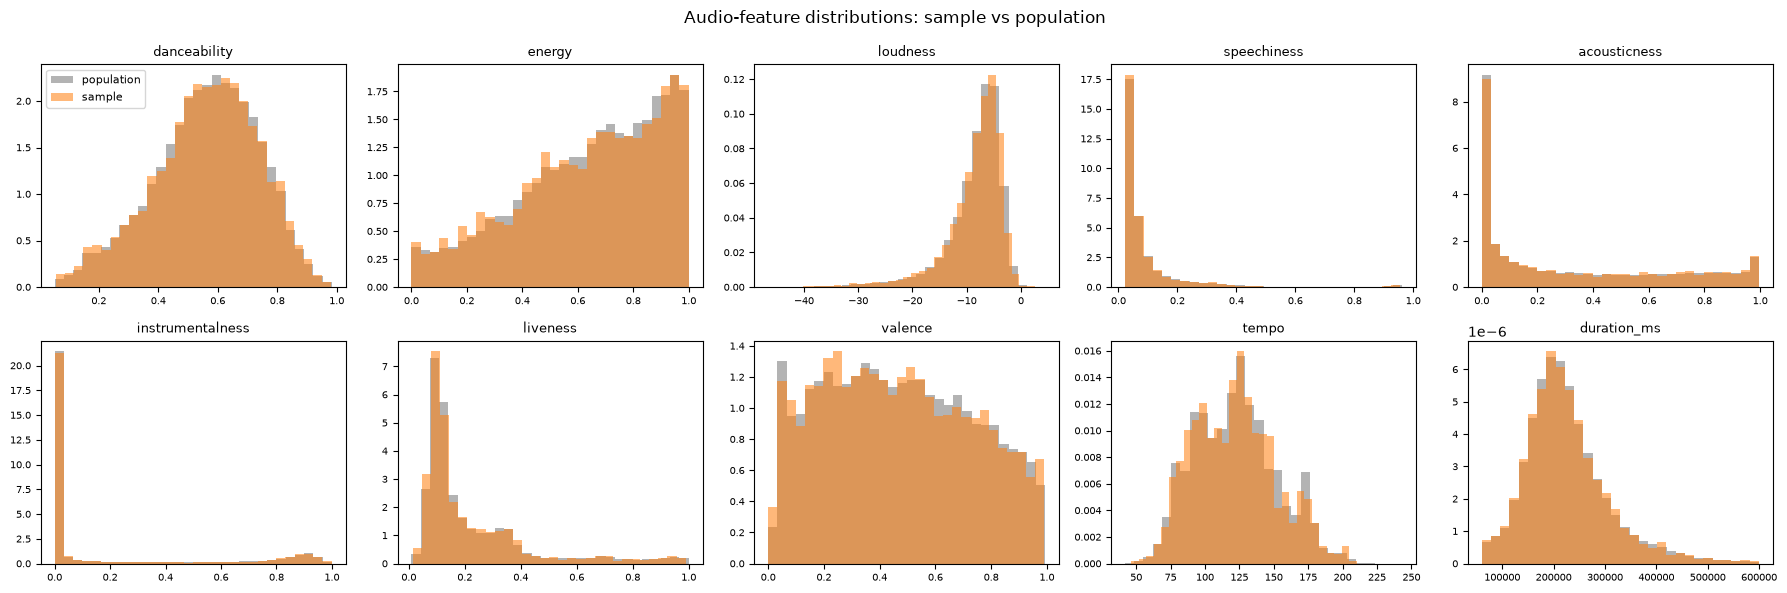

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, f in zip(axes.ravel(), FEATURES):
    ax.hist(pop[f], bins=30, density=True, color="0.7", label="population")
    ax.hist(sample[f], bins=30, density=True, color="tab:orange", alpha=0.55, label="sample")
    ax.set_title(f, fontsize=9)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Audio-feature distributions: sample vs population", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Download the audio

For each sampled track we call `spotify_dl` into its **own folder**
`data/audio/<spotify_track_id>/`. Per-track folders make it trivial to map a
file back to its id no matter how `spotify_dl` names the mp3 internally — we just
glob for the mp3 inside. Tracks already downloaded are skipped, failures are
logged and we keep going.

In [8]:
# Credential guard — reads from the environment, never stores secrets.
from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

missing = [v for v in ("SPOTIPY_CLIENT_ID", "SPOTIPY_CLIENT_SECRET") if not os.getenv(v)]
if missing:
    raise EnvironmentError(
        "Missing Spotify API credentials: " + ", ".join(missing) + "\n"
        "Create a free app at https://developer.spotify.com/dashboard and, in the shell "
        "you launched Jupyter from, run:\n"
        "  export SPOTIPY_CLIENT_ID=your_client_id\n"
        "  export SPOTIPY_CLIENT_SECRET=your_client_secret\n"
        "Then restart the kernel. Do NOT paste secrets into this notebook."
    )
print("Spotify credentials found in environment.")
SPOTIPY_CLIENT_ID = os.getenv('SPOTIPY_CLIENT_ID')
SPOTIPY_CLIENT_SECRET = os.getenv('SPOTIPY_CLIENT_SECRET')

Spotify credentials found in environment.


In [9]:
# ---- Download audio via yt-dlp directly (no Spotify API -> sidesteps the lockdown) ----
# The dataset already has artist + title, which is all spotify_dl fetched from
# Spotify before handing off to yt-dlp. So we skip Spotify entirely: yt-dlp
# searches YouTube and extracts mp3. We reject wrong-length hits (remix/cover/
# live) using each track's known duration_ms.
import subprocess, time

DURATION_TOL = 20   # sec: reject YouTube results whose length is off by more than this
YTSEARCH_N   = 5    # inspect up to N search hits; keep the first that passes the filter

def audio_path(tid):
    f = AUDIO_DIR / f"{tid}.mp3"
    return str(f.relative_to(ROOT)) if f.exists() else None

results = []
for i, row in sample.iterrows():
    tid = row[ID_COL]
    if (AUDIO_DIR / f"{tid}.mp3").exists():          # already downloaded -> skip
        status = "skipped_existing"
    else:
        artist = row["primary_artist"]
        if not isinstance(artist, str) or not artist:
            artist = str(row.get("artists", ""))
        query = f"{artist} {row['track_name']}".strip()
        dur = row["duration_ms"] / 1000.0
        lo, hi = dur - DURATION_TOL, dur + DURATION_TOL
        cmd = [
            "yt-dlp", "-x", "--audio-format", "mp3", "--audio-quality", "0",
            "--no-playlist", "--default-search", "ytsearch",
            "--match-filter", f"duration>={lo:.0f} & duration<={hi:.0f}",
            "--max-downloads", "1",                  # stop after first passing hit
            "-o", str(AUDIO_DIR / f"{tid}.%(ext)s"),
            f"ytsearch{YTSEARCH_N}:{query}",
        ]
        try:
            # --max-downloads makes yt-dlp exit non-zero on success, so judge by
            # whether the mp3 actually landed, not by the return code.
            subprocess.run(cmd, capture_output=True, text=True, timeout=DOWNLOAD_TIMEOUT)
            status = "ok" if (AUDIO_DIR / f"{tid}.mp3").exists() else "no_match"
        except subprocess.TimeoutExpired:
            status = "timeout"
        time.sleep(SLEEP_BETWEEN)

    rec = row.to_dict()
    rec["download_status"] = status
    rec["audio_path"] = audio_path(tid)
    results.append(rec)
    name = str(row.get("track_name", ""))[:45]
    print(f"[{i + 1:>2}/{len(sample)}] {tid}  {name!r:47}  -> {status}")

[4340/5975] 6M71YDFupcg9UTkR1ED57g  'Let There Be Light'                             -> ok


python(7491) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[4341/5975] 4RNLZEWEekwQuttSPONJHB  'Breathe Hardstyle'                              -> ok


python(7573) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[4342/5975] 7KuYN3fAlt1JM689zzx3wJ  'Fjäll'                                          -> ok


...

[5973/5975] 1mOhRdYfCMLbyzrQPPcGMG  'Añejo W'                                        -> no_match


python(19148) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[5974/5975] 4ZUZYAvrc6Ib8cA1oDObdz  'Megaman'                                        -> ok


python(19227) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[5975/5975] 1wjj7LDz8ZCU6HOldxvd6Q  'Juggernaut'                                     -> ok


## 5. Save a manifest (id → file → features) for Stage 6

In [15]:
# This run downloaded only the NEW tracks, so APPEND to the existing manifest
# rather than overwrite it. De-dup by id, keeping the latest status for any id
# seen twice (e.g. a previous no_match that we retried).
new_manifest = pd.DataFrame(results)
manifest_path = AUDIO_DIR / "manifest.csv"

if manifest_path.exists():
    old_manifest = pd.read_csv(manifest_path)
    manifest = (pd.concat([old_manifest, new_manifest], ignore_index=True)
                  .drop_duplicates(ID_COL, keep="last")
                  .reset_index(drop=True))
else:
    manifest = new_manifest

manifest.to_csv(manifest_path, index=False)

n_ok = (manifest["download_status"].isin(["ok", "skipped_existing"])).sum()
print(f"New rows this run: {len(new_manifest):,} | manifest total now: {len(manifest):,}")
print(f"Present (ok/skipped): {n_ok}/{len(manifest)}")
print("Status counts (combined):")
print(manifest["download_status"].value_counts().to_string())
print(f"\nManifest written to: {manifest_path.relative_to(ROOT)}")
manifest[[ID_COL, "track_name", "download_status", "audio_path"]].head(10)

New rows this run: 5,975 | manifest total now: 15,734
Present (ok/skipped): 14106/15734
Status counts (combined):
download_status
ok                  11584
skipped_existing     2522
no_match             1569
timeout                59

Manifest written to: data/audio/manifest.csv


,spotify_track_id,track_name,download_status,audio_path
0,2EZwmBwxtpZeAiV7444CSy,Agua,skipped_existing,data/audio/2EZwmBwxtpZeAiV7444CSy.mp3
1,0Rvf9O6mzFqezZgWkdlxJt,Pen Poove,skipped_existing,data/audio/0Rvf9O6mzFqezZgWkdlxJt.mp3
2,2EuPcc2kzFNbv3Ec2BAPLp,Say Something Do Nothing - New Master Cut Mix,skipped_existing,data/audio/2EuPcc2kzFNbv3Ec2BAPLp.mp3
3,2X45nVBeYzmDlrXji9Av0Q,"Love, Maybe",skipped_existing,data/audio/2X45nVBeYzmDlrXji9Av0Q.mp3
4,3bviXo8C7OAuhIA9U9cQMH,Happiness Jones/Express Yourself - Live at the...,skipped_existing,data/audio/3bviXo8C7OAuhIA9U9cQMH.mp3
5,7JE16VzmuDrVmRgQZTp9OG,Bimbim Jangan Menangis,skipped_existing,data/audio/7JE16VzmuDrVmRgQZTp9OG.mp3
6,3zzW9CIHxiPbeQrGmBVvG6,EG-ENERGY,skipped_existing,data/audio/3zzW9CIHxiPbeQrGmBVvG6.mp3
7,3erARuIHWb4koIi36ZVEF6,Y Todavía Te Quiero,skipped_existing,data/audio/3erARuIHWb4koIi36ZVEF6.mp3
8,0b93tWwuoAC0nXe1CfR30I,Star Treatment,skipped_existing,data/audio/0b93tWwuoAC0nXe1CfR30I.mp3
9,46uMTUcbm48oFMWOCGLMe4,Drunk Glenn,skipped_existing,data/audio/46uMTUcbm48oFMWOCGLMe4.mp3


## Data Checkup & cleaning

In [16]:
data_with_mp3 = pd.read_csv(ROOT / "data" / 'audio' / 'manifest.csv')
data_with_mp3 = data_with_mp3.dropna().reset_index(drop=True)

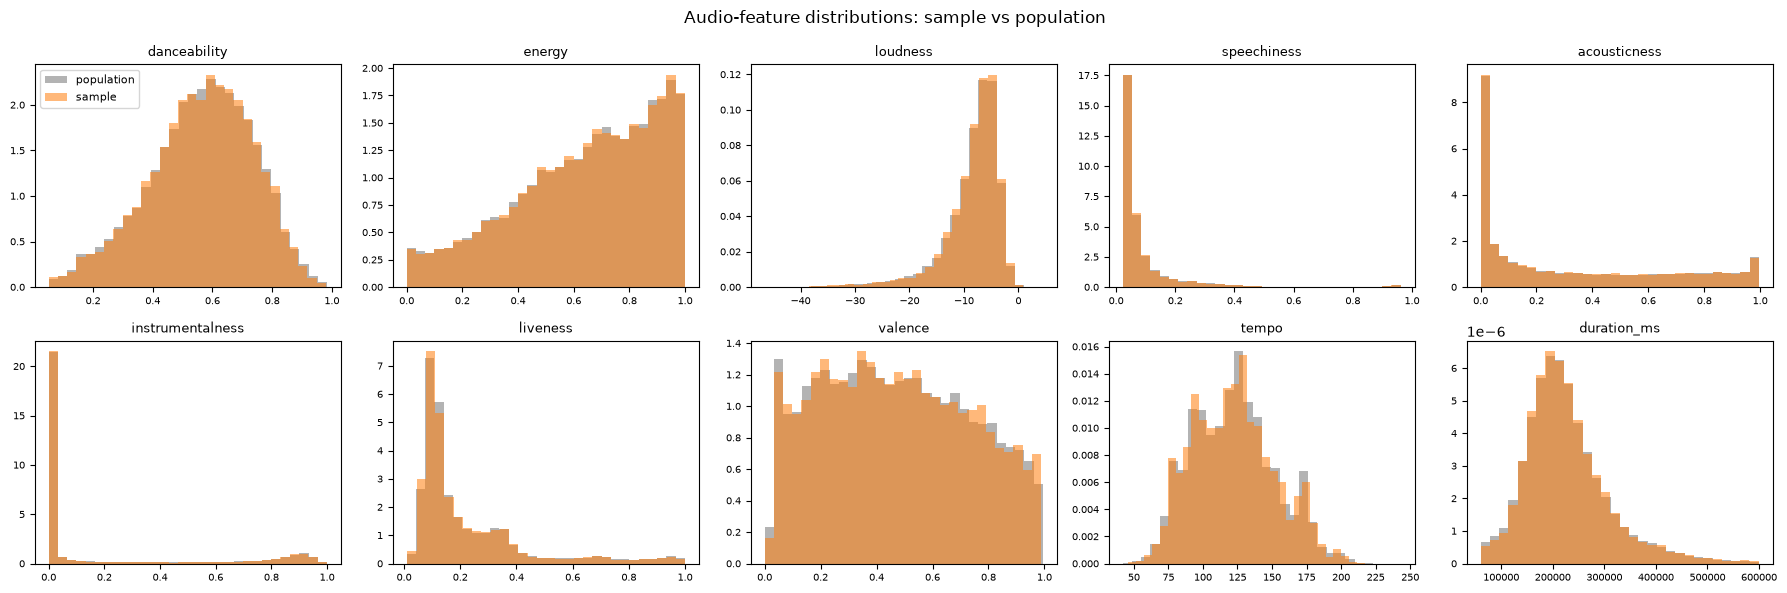

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, f in zip(axes.ravel(), FEATURES):
    ax.hist(df[f], bins=30, density=True, color="0.7", label="population")
    ax.hist(data_with_mp3[f], bins=30, density=True, color="tab:orange", alpha=0.55, label="sample")
    ax.set_title(f, fontsize=9)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Audio-feature distributions: sample vs population", fontsize=12)
fig.tight_layout()
plt.show()

In [18]:
print(mean_ks(data_with_mp3, df, FEATURES))

0.006796661609747154


In [19]:
data_with_mp3.to_parquet(ROOT / 'data' / 'processed' / 'data_with_mp3.parquet')
data_with_mp3.to_csv(ROOT / 'data' / 'processed' / 'manifest.csv')